# AG-HYPOPT · Trial 11

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Ten trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803; then trial_05 (0.0822), trial_09 (0.0839), trial_06 (0.0861), trial_08 (0.0876), trial_10 (0.0922). All 0 diverged, gamma finite. The optimum region is a tight cluster (strong sw ~0.85, h_f ~3.9-4.0, h_s ~3.6-3.7, gamma cap near ~0.1). The gamma cap is now bracketed: trial_10 (0.083) and trials 08/09 (0.23-0.30) are both worse than trial_07 (0.107), so the cap optimum is a narrow band near 0.1-0.15. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_11'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (10/5 trials)
ID |     ei | params
 1 | 3.6525 | {"gamma_rel_cap": 0.24963893122005748, "h_f_scale": 3.9754405268591877, "h_s_scale": 3.730791336101386, "sigma_weight": 0.12977394939929798}
 2 | 3.4149 | {"gamma_rel_cap": 0.11518966416934788, "h_f_scale": 3.9953590237036085, "h_s_scale": 3.6705930115166314, "sigma_weight": 0.7880395945039919}
 3 | 3.9261 | {"gamma_rel_cap": 0.20625994518399815, "h_f_scale": 3.9365734941087442, "h_s_scale": 3.5719306131196005, "sigma_weight": 0.8580001347047497}
 4 | 3.2778 | {"gamma_rel_cap": 0.06278912681911622, "h_f_scale": 3.258260064169313, "h_s_scale": 3.6173642521423535, "sigma_weight": 0.8624922049932986}
 5 | 3.9857 | {"gamma_rel_cap": 0.44797215412518376, "h_f_scale": 3.9855614343388726, "h_s_scale": 3.6468396934148672, "sigma_weight": 0.8357820598022416}
 6 | 3.9575 | {"gamma_rel_cap": 0.10038447708060966, "h_f_scale": 3.938177171022458, "h_s_scale": 3.59173883735801, "sigma_weight": 0.8661846466609486}
 7 | 3.8414 | {"gamma_r

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Optimum region established: sw ~0.85, h_f ~3.9-4.0, h_s ~3.6-3.7, gamma cap ~0.1. The cap is bracketed (0.083 and 0.23-0.30 both worse than 0.107). The remaining slack is the sigma weight: the lowest-sw run (trial_06, 0.497) had the best mu (34.0%) but the worst gamma (30.1%), so a modest reduction of sw from 0.865 is a plausible way to trade a little gamma for mu.

Candidate 2 (ei 3.4149) stays in the region (h_f 3.995, h_s 3.671, cap 0.115) with sigma_weight 0.788, a modest step below trial_07's 0.865; the top-ei alternatives either repeat trial_07 nearly exactly (id 6) or set clearly unhelpful caps (id 5, 0.448). It is the cleanest in-region probe of a slightly lower sigma weight.

I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # candidate 2: sigma_weight 0.788, h_f_scale 3.995, h_s_scale 3.671, gamma_rel_cap 0.115 (in-region, slightly lower sw)


chosen: {'gamma_rel_cap': 0.11518966416934788, 'h_f_scale': 3.9953590237036085, 'h_s_scale': 3.6705930115166314, 'sigma_weight': 0.7880395945039919}
Running  1nW Trans05 ... 

μ 9.39 -> 5.92 | γ 8.5 -> 4.49 | NLL 0.24


Running  1nW Trans20 ... 

μ 17.32 -> 27.72 | γ 8.5 -> 5.43 | NLL 0.63


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 66.70 | γ 14.1 -> 14.00 | NLL 0.69


Running 3nW Trans100 ... 

μ 175.71 -> 98.99 | γ 14.1 -> 13.79 | NLL 0.66



Total: 7.6 min


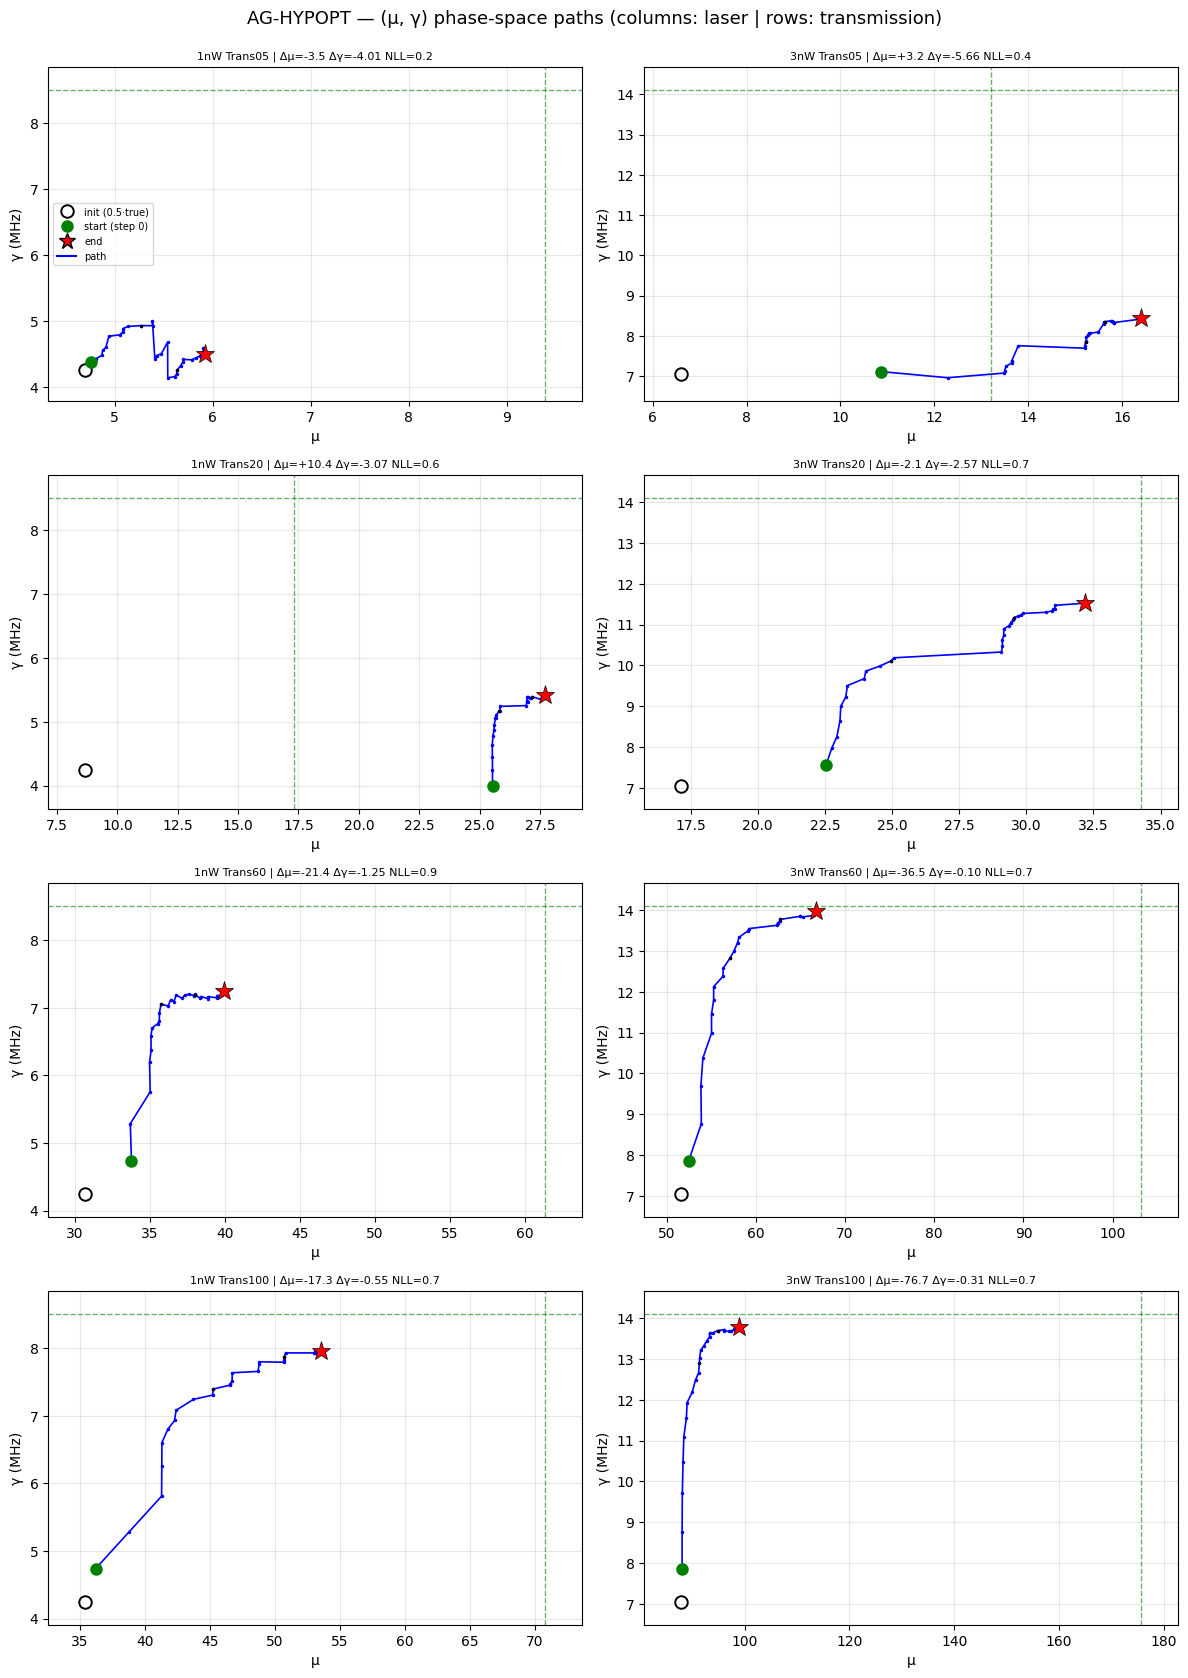

trial finished in 7.7 min
objective = 0.0859 ± 0.0250
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.92   -36.9 |     8.50    4.49   -47.2
1nW Trans20       17.32   27.72   +60.1 |     8.50    5.43   -36.2
1nW Trans60       61.37   39.95   -34.9 |     8.50    7.25   -14.7
1nW Trans100       70.82   53.55   -24.4 |     8.50    7.95    -6.4
3nW Trans05       13.20   16.41   +24.3 |    14.10    8.44   -40.1
3nW Trans20       34.28   32.19    -6.1 |    14.10   11.53   -18.2
3nW Trans60      103.20   66.70   -35.4 |    14.10   14.00    -0.7
3nW Trans100      175.71   98.99   -43.7 |    14.10   13.79    -2.2

weighted objective (T-graded, cap=1.0) = 0.0859 | diverged cells: 0
μ: RMSE 31.840 (rel 36.3%, bias -17.982) | γ: RMSE 2.875 (rel 26.8%, bias -2.191)


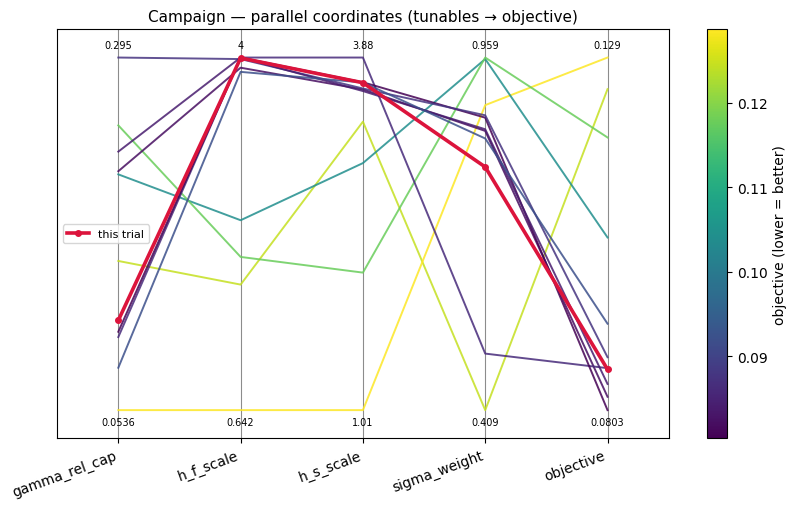

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 11 (sw 0.788, h_f 3.995, h_s 3.671, cap 0.115) ran to completion in 7.7 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0859 +/- 0.0250 - worse than trial_07 (0.0803), sitting between trial_09 (0.0839) and trial_06 (0.0861).

mu rel-RMSE 36.3% (essentially trial_07's 35.9%); same shape - high-T undershoot (3nW Trans100 -43.7%, 3nW Trans60 -35.4%, 1nW Trans60 -34.9%, 1nW Trans100 -24.4%), low-T overshoot (1nW Trans20 +60.1%, 3nW Trans05 +24.3%); bias -17.98.

gamma rel-RMSE 26.8% (worse than trial_07's 22.3%): low T under-estimated (1nW Trans05 -47.2%, 3nW Trans05 -40.1%, 1nW Trans20 -36.2%), high T near truth (-0.7%, -2.2%).

The candidate held the near-optimal kernels and cap (h_f 3.995, h_s 3.671, cap 0.115) and only lowered the sigma weight to 0.788. mu was unchanged while gamma worsened, so within the optimum region trial_07's stronger sigma weight (0.865) remains preferable.

**Summary:** Trial 11 (sw=0.788, h_f=3.995, h_s=3.671, cap=0.115) finished in 7.7 min with 0 diverged cells and gamma finite, objective 0.0859 +/- 0.0250 - worse than trial_07 (mu rel-RMSE 36.3%, gamma rel-RMSE 26.8%).
**Key insight:** Lowering the sigma weight slightly (0.865 -> 0.788) within the optimum region did not help (0.0859 vs 0.0803), so trial_07's strong sigma weight remains the best value.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 11 (sw=0.788, h_f=3.995, h_s=3.671, cap=0.115): objective 0.0859 +/- 0.0250 - worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 36.3%, gamma rel-RMSE 26.8%).'
KEY_INSIGHT = 'Lowering the sigma weight slightly (0.865 -> 0.788) within the optimum region did not help (0.0859 vs 0.0803), so trial_07 strong sigma weight remains the best value.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_11 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_12.ipynb. Open it and follow its cells from the top.
